In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("elikplim/car-evaluation-data-set")

print("Path to dataset files:", path)

100%|██████████| 4.66k/4.66k [00:00<00:00, 7.02MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/elikplim/car-evaluation-data-set/versions/1


In [ ]:
import pandas as pd
import os

print(os.listdir(path))
df = pd.read_csv(os.path.join(path, "car_evaluation.csv"))

['car_evaluation.csv']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
df = pd.read_csv(os.path.join(path, "car_evaluation.csv"))

print(df.head())

print(df.info())

print(df.isnull().sum())

   vhigh vhigh.1  2 2.1  small   low  unacc
0  vhigh   vhigh  2   2  small   med  unacc
1  vhigh   vhigh  2   2  small  high  unacc
2  vhigh   vhigh  2   2    med   low  unacc
3  vhigh   vhigh  2   2    med   med  unacc
4  vhigh   vhigh  2   2    med  high  unacc
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   vhigh    1727 non-null   object
 1   vhigh.1  1727 non-null   object
 2   2        1727 non-null   object
 3   2.1      1727 non-null   object
 4   small    1727 non-null   object
 5   low      1727 non-null   object
 6   unacc    1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB
None
vhigh      0
vhigh.1    0
2          0
2.1        0
small      0
low        0
unacc      0
dtype: int64


In [ ]:
import os
import pandas as pd

columns = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety",
    "class"
]

df = pd.read_csv(
    os.path.join(path, "car_evaluation.csv"),
    header=None,
    names=columns
)

print(df.head())
print(df.columns)

  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc
Index(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class'], dtype='object')


In [ ]:
print(df.head())

  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc


In [ ]:
encoder = LabelEncoder()

for column in df.columns:
    df[column] = encoder.fit_transform(df[column])

In [ ]:
X = df.drop("class", axis=1)
Y = df["class"]
df.info()
print("X Shape :", X.shape)
print("Y Shape :", Y.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   int64
 1   maint     1728 non-null   int64
 2   doors     1728 non-null   int64
 3   persons   1728 non-null   int64
 4   lug_boot  1728 non-null   int64
 5   safety    1728 non-null   int64
 6   class     1728 non-null   int64
dtypes: int64(7)
memory usage: 94.6 KB
X Shape : (1728, 6)
Y Shape : (1728,)


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)


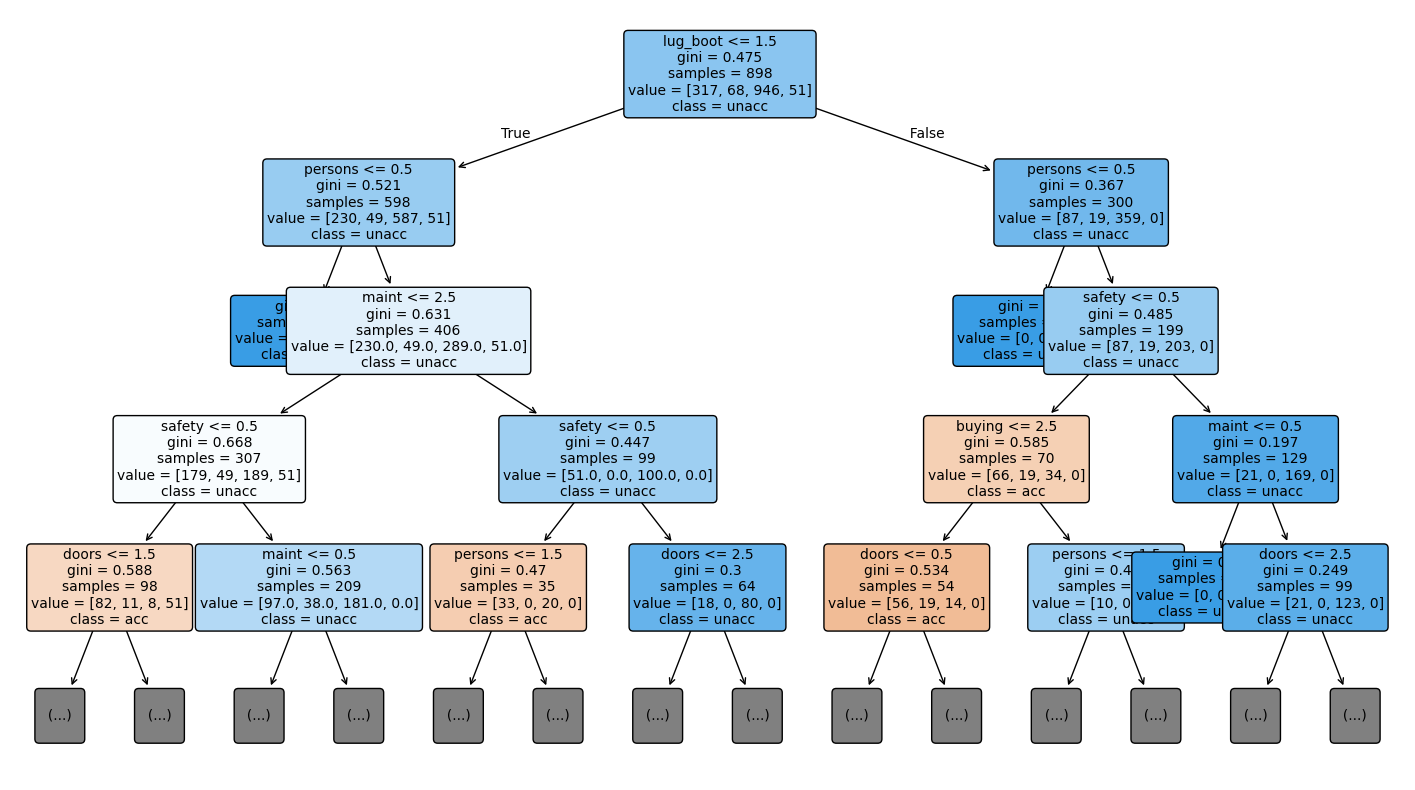

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

plot_tree(
    model.estimators_[8],
    feature_names=X.columns,
    class_names=["acc", "good", "unacc", "vgood"],
    filled=True,
    rounded=True,
    max_depth=4,      # Show only first 4 levels
    fontsize=10
)

plt.show()

In [ ]:
accuracy = accuracy_score(Y_test, Y_pred)

print("Accuracy :", accuracy)


Accuracy : 0.9739884393063584


In [ ]:
cm = confusion_matrix(Y_test, Y_pred)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[ 75   6   2   0]
 [  0  11   0   0]
 [  0   0 235   0]
 [  1   0   0  16]]


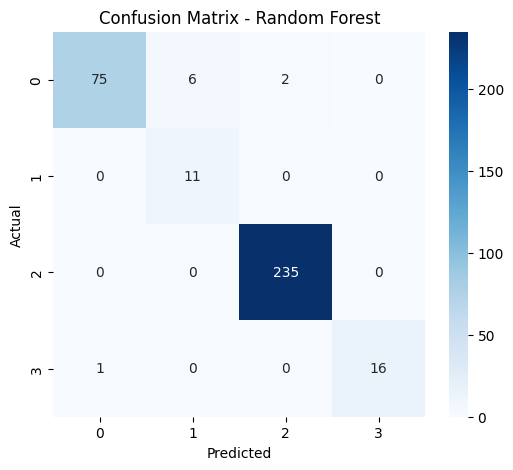

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [ ]:
print("Classification Report")
print(classification_report(Y_test, Y_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.99      0.90      0.94        83
           1       0.65      1.00      0.79        11
           2       0.99      1.00      1.00       235
           3       1.00      0.94      0.97        17

    accuracy                           0.97       346
   macro avg       0.91      0.96      0.92       346
weighted avg       0.98      0.97      0.98       346



In [ ]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)


    Feature  Importance
5    safety    0.276100
3   persons    0.218374
0    buying    0.190115
1     maint    0.162154
4  lug_boot    0.085626
2     doors    0.067631


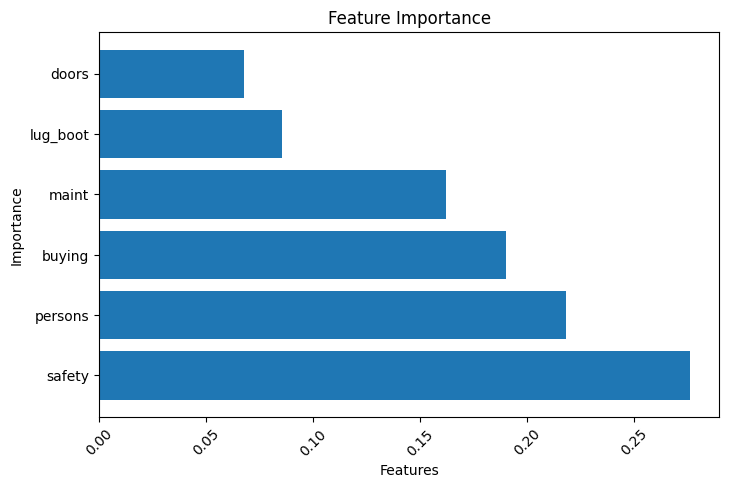

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(feature_importance["Feature"],
        feature_importance["Importance"])

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

In [ ]:
new_car = pd.DataFrame(
    [[1, 0, 2, 2, 0, 0]],
    columns=X.columns
)

prediction = model.predict(new_car)

print("Encoded Prediction:", prediction)

Encoded Prediction: [3]
